# 4. Marketing Campaign Performance Analysis:
4.1. Assess and compare the performance of individual campaigns based on lead volume and conversion efficiency.
4.2. Analyze the contribution of various acquisition channels (Source) to the generation of high-quality, conversion-ready leads.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np

For campaign effectiveness analysis, we use 3 tables: Deals_clean, Contacts_clean, and Spend_clean. We load the datasets and verify their shape and data types for additional quality control.

In [2]:
df_deals = pd.read_pickle("../processed/Deals_clean.pkl")
df_contacts = pd.read_pickle("../processed/Contacts_clean.pkl")
df_spend = pd.read_pickle("../processed/Spend_clean.pkl")

In [3]:
print(df_deals.dtypes)
print(df_deals.shape)

Id                      string[python]
Deal Owner Name         string[python]
Closing Date            datetime64[ns]
Quality                         object
Stage                           object
Lost Reason                     object
Campaign                        object
SLA                    timedelta64[ns]
Content                         object
Term                            object
Source                          object
Payment Type                    object
Product                         object
Education Type                  object
Created Time            datetime64[ns]
Course duration                float64
Months of study                float64
Initial Amount Paid            float64
Offer Total Amount             float64
Contact Name            string[python]
City                            object
Level of Deutsch        string[python]
SLA_status                      object
level_norm                      object
dtype: object
(21593, 24)


In [4]:
print(df_contacts.dtypes)
print(df_contacts.shape)

Id                    string[python]
Contact Owner Name    string[python]
Created Time          datetime64[ns]
Modified Time         datetime64[ns]
dtype: object
(18548, 4)


In [5]:
print(df_spend.dtypes)
print(df_spend.shape)

Date           datetime64[ns]
Source                 object
Campaign               object
Impressions             int64
Spend                 float64
Clicks                  int64
AdGroup                object
Ad                     object
dtype: object
(19862, 8)


4.1. Comparing Campaign Effectiveness in Terms of Lead Generation and Conversion Rate
Evaluate the conversion rate at each stage of the funnel:
Customer responded to the ad (impression/engagement);
Customer clicked the link (click-through);
Customer submitted contact information (lead captured);
Deal closed with the customer (conversion to payment).


Step 1. Merging Spend and Deals on Campaign
Both the Spend and Deals datasets include a "Campaign" field, which serves as the primary key for merging.
Before joining, aggregate the Spend data to ensure one row per Campaign (summing metrics like Impressions, Clicks, and Spend).

In [6]:
spend_agg = (
    df_spend.groupby("Campaign", dropna=False)
    .agg({
        "Impressions": "sum",
        "Clicks": "sum",
        "Spend": "sum"})
    .reset_index())
spend_agg

,Campaign,Impressions,Clicks,Spend
0,01.02.24wide_webinar_DE,18047,195,189.91
1,01.04.23women_PL,45956,367,357.25
2,02.05.24test_DE,20047,790,164.04
3,02.07.23wide_DE,594807,10281,6913.60
4,02.08.23interests_DE,5990,76,69.30
5,03.07.23women,348089,7139,4219.75
6,04.07.23recentlymoved_DE,417891,7611,4523.31
7,05.07.23interests_DE,26833,425,333.73
8,05.09.2023wide_DE,60420,350,244.51
9,07.07.23LAL_DE,335725,5813,4200.37


Step  2. Counting Leads (Contact submissions)
If the Contacts table contains Created Time and Id but does not have a Campaign field,
we pull Campaign from the Deals table: a contact counts as a lead only when it is associated with a created deal.


In [7]:
leads_agg = (
    df_deals
    .groupby("Campaign")['Contact Name']
    .nunique()
    .reset_index(name="leads_count"))
leads_agg

,Campaign,leads_count
0,01.04.23women_PL,31
1,02.05.24test_DE,120
2,02.07.23wide_DE,942
3,02.08.23interests_DE,8
4,03.07.23women,600
...,...,...
150,work_wr,6
151,workingin_DE,46
152,yo_DE,13
153,youtube_shorts_DE,1521


Step  3. The table shows the number of successful (non-Lost) deals generated by each campaign.

In [8]:
deals_agg = (
    df_deals[df_deals["Stage"] != "Lost"]
    .groupby("Campaign")["Contact Name"]
    .nunique()
    .reset_index(name="deals_count"))
deals_agg

,Campaign,deals_count
0,01.04.23women_PL,4
1,02.05.24test_DE,74
2,02.07.23wide_DE,193
3,03.07.23women,138
4,04.07.23recentlymoved_DE,153
...,...,...
115,work_DE,63
116,workingin_DE,5
117,yo_DE,2
118,youtube_shorts_DE,313


Step 4. Paid Deals Count per Campaign.

In [9]:
paid_agg = (
    df_deals[
        (df_deals["Stage"] == "Payment Done") &
        (df_deals["Initial Amount Paid"] >= 100)
    ]
    .groupby("Campaign")["Id"]
    .nunique()
    .reset_index(name="paid_count"))
paid_agg

,Campaign,paid_count
0,02.05.24test_DE,1
1,02.07.23wide_DE,52
2,03.07.23women,29
3,04.07.23recentlymoved_DE,30
4,05.09.2023wide_DE,1
...,...,...
63,web2311_DE,3
64,web2408_DE,5
65,webinar1604,3
66,work_DE,9


In [10]:
leads = leads_agg['leads_count'].sum()
deals = deals_agg['deals_count'].sum()
paid = paid_agg['paid_count'].sum()
print(leads, deals, paid)

20463 5661 839


Step 5. Merging all tables into one, Fill missing values (blank)  with zeros

In [11]:
funnel_campaign = (
    spend_agg
    .merge(leads_agg, on="Campaign", how="left")
    .merge(deals_agg, on="Campaign", how="left")
    .merge(paid_agg, on="Campaign", how="left"))

funnel_campaign = funnel_campaign.fillna(0)
funnel_campaign

,Campaign,Impressions,Clicks,Spend,leads_count,deals_count,paid_count
0,01.02.24wide_webinar_DE,18047,195,189.91,0.0,0.0,0.0
1,01.04.23women_PL,45956,367,357.25,31.0,4.0,0.0
2,02.05.24test_DE,20047,790,164.04,120.0,74.0,1.0
3,02.07.23wide_DE,594807,10281,6913.60,942.0,193.0,52.0
4,02.08.23interests_DE,5990,76,69.30,8.0,0.0,0.0
5,03.07.23women,348089,7139,4219.75,600.0,138.0,29.0
6,04.07.23recentlymoved_DE,417891,7611,4523.31,739.0,153.0,30.0
7,05.07.23interests_DE,26833,425,333.73,36.0,2.0,0.0
8,05.09.2023wide_DE,60420,350,244.51,6.0,2.0,1.0
9,07.07.23LAL_DE,335725,5813,4200.37,530.0,165.0,28.0


In [12]:
funnel_campaign["Campaign"] = funnel_campaign["Campaign"].astype(str)
funnel_campaign.to_parquet(
    "../processed/parquet/4_funnel_campaign.parquet", 
    index=False
)

Step 6. Calculating Conversion Rates at Each Funnel Stage


In [13]:
funnel_campaign["CTR"] = (funnel_campaign["Clicks"] / funnel_campaign["Impressions"]).round(6)
funnel_campaign["Lead_rate"] = (funnel_campaign["leads_count"] / funnel_campaign["Clicks"]).round(6)

funnel_campaign["Deal_rate"] = (funnel_campaign["deals_count"] / funnel_campaign["leads_count"]).round(6)
funnel_campaign["Paid_rate"] = (funnel_campaign["paid_count"] / funnel_campaign["deals_count"]).round(6)
funnel_campaign["Total_conversion"] = (funnel_campaign["paid_count"] / funnel_campaign["Clicks"]).round(6)
funnel_campaign = funnel_campaign.replace([np.inf, -np.inf], np.nan).fillna(0)

funnel_sorted = funnel_campaign.sort_values("Total_conversion", ascending=False).reset_index(drop=True)
funnel_sorted

,Campaign,Impressions,Clicks,Spend,leads_count,deals_count,paid_count,CTR,Lead_rate,Deal_rate,Paid_rate,Total_conversion
0,web2408_DE,9315,154,189.04,145.0,36.0,5.0,0.016532,0.941558,0.248276,0.138889,0.032468
1,blog2_DE,16100,249,773.00,273.0,56.0,6.0,0.015466,1.096386,0.205128,0.107143,0.024096
2,20.05.24wide_DE,5870,94,76.72,8.0,3.0,1.0,0.016014,0.085106,0.375000,0.333333,0.010638
3,brand_search_eng_DE,7783,2244,3457.82,165.0,71.0,15.0,0.288321,0.073529,0.430303,0.211268,0.006684
4,15.07.23b_DE,54268,881,1256.50,131.0,14.0,5.0,0.016234,0.148695,0.106870,0.357143,0.005675
5,02.07.23wide_DE,594807,10281,6913.60,942.0,193.0,52.0,0.017285,0.091625,0.204883,0.269430,0.005058
6,07.07.23LAL_DE,335725,5813,4200.37,530.0,165.0,28.0,0.017315,0.091175,0.311321,0.169697,0.004817
7,12.09.23interests_Uxui_DE,319463,6301,3753.06,517.0,110.0,26.0,0.019724,0.082050,0.212766,0.236364,0.004126
8,24.09.23retargeting_DE,252080,4143,2817.29,471.0,105.0,17.0,0.016435,0.113686,0.222930,0.161905,0.004103
9,03.07.23women,348089,7139,4219.75,600.0,138.0,29.0,0.020509,0.084045,0.230000,0.210145,0.004062


In [14]:
funnel_sorted["Campaign"] = funnel_sorted["Campaign"].astype(str)
funnel_sorted.to_parquet(
    "../processed/parquet/4_funnel_sorted.parquet", 
    index=False
)

Step 7. Filter Campaigns with Positive Conversion.

In [15]:
funnel_nonzero = funnel_sorted[funnel_sorted["Total_conversion"] > 0].reset_index(drop=True)
funnel_nonzero

,Campaign,Impressions,Clicks,Spend,leads_count,deals_count,paid_count,CTR,Lead_rate,Deal_rate,Paid_rate,Total_conversion
0,web2408_DE,9315,154,189.04,145.0,36.0,5.0,0.016532,0.941558,0.248276,0.138889,0.032468
1,blog2_DE,16100,249,773.00,273.0,56.0,6.0,0.015466,1.096386,0.205128,0.107143,0.024096
2,20.05.24wide_DE,5870,94,76.72,8.0,3.0,1.0,0.016014,0.085106,0.375000,0.333333,0.010638
3,brand_search_eng_DE,7783,2244,3457.82,165.0,71.0,15.0,0.288321,0.073529,0.430303,0.211268,0.006684
4,15.07.23b_DE,54268,881,1256.50,131.0,14.0,5.0,0.016234,0.148695,0.106870,0.357143,0.005675
5,02.07.23wide_DE,594807,10281,6913.60,942.0,193.0,52.0,0.017285,0.091625,0.204883,0.269430,0.005058
6,07.07.23LAL_DE,335725,5813,4200.37,530.0,165.0,28.0,0.017315,0.091175,0.311321,0.169697,0.004817
7,12.09.23interests_Uxui_DE,319463,6301,3753.06,517.0,110.0,26.0,0.019724,0.082050,0.212766,0.236364,0.004126
8,24.09.23retargeting_DE,252080,4143,2817.29,471.0,105.0,17.0,0.016435,0.113686,0.222930,0.161905,0.004103
9,03.07.23women,348089,7139,4219.75,600.0,138.0,29.0,0.020509,0.084045,0.230000,0.210145,0.004062


Step 8. Preparing the Table for Heatmap

In [16]:

conv_cols = ["CTR", "Lead_rate", "Deal_rate", "Paid_rate", "Total_conversion"]
heatmap_data = funnel_nonzero.set_index("Campaign")[conv_cols].T
heatmap_data_percent = (heatmap_data * 100).round(2)
heatmap_data_percent

Campaign,web2408_DE,blog2_DE,20.05.24wide_DE,brand_search_eng_DE,15.07.23b_DE,02.07.23wide_DE,07.07.23LAL_DE,12.09.23interests_Uxui_DE,24.09.23retargeting_DE,03.07.23women,...,15.03.2024wide_AT,22.05.2024wide_DE,02.05.24test_DE,20.03.2024wide_PL,youtube_shorts_DE,08.04.24wide_webinar_DE,performancemax_wide_AT,1performancemax_wide_PL,discovery_DE,performancemax_eng_DE
CTR,1.65,1.55,1.60,28.83,1.62,1.73,1.73,1.97,1.64,2.05,...,0.25,0.48,3.94,0.28,0.68,0.86,0.78,0.46,0.82,0.76
Lead_rate,94.16,109.64,8.51,7.35,14.87,9.16,9.12,8.20,11.37,8.40,...,2.19,6.64,15.19,3.84,2.63,25.41,1.62,2.16,0.17,0.15
Deal_rate,24.83,20.51,37.50,43.03,10.69,20.49,31.13,21.28,22.29,23.00,...,9.09,42.86,61.67,8.33,20.58,95.32,21.95,3.94,37.23,14.46
Paid_rate,13.89,10.71,33.33,21.13,35.71,26.94,16.97,23.64,16.19,21.01,...,100.00,6.67,1.35,30.00,16.93,0.38,22.22,40.00,5.71,2.86
Total_conversion,3.25,2.41,1.06,0.67,0.57,0.51,0.48,0.41,0.41,0.41,...,0.20,0.19,0.13,0.10,0.09,0.09,0.08,0.03,0.00,0.00


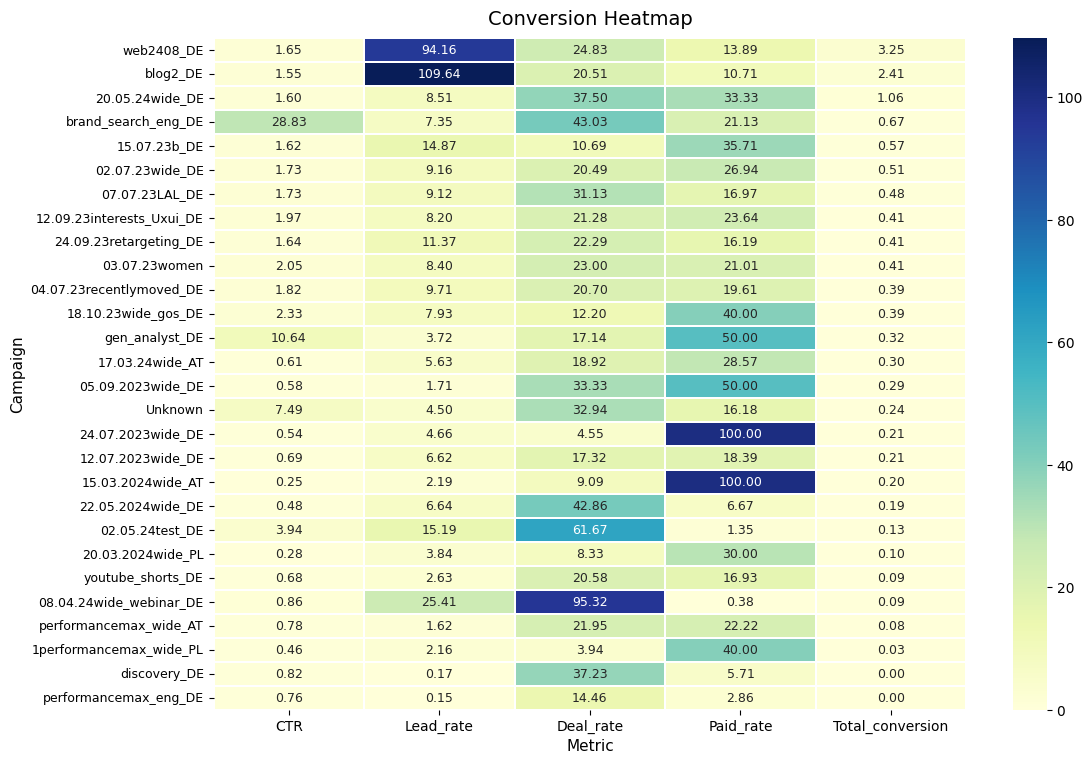

In [17]:
conv_cols = ["CTR", "Lead_rate", "Deal_rate", "Paid_rate", "Total_conversion"]

heatmap_data = funnel_nonzero.set_index("Campaign")[conv_cols]
heatmap_data_percent = (heatmap_data * 100).round(2)

plt.figure(figsize=(12, 8))  

sns.heatmap(
    heatmap_data_percent,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.3,          
    annot_kws={"size": 9}    
)

plt.title("Conversion Heatmap", fontsize=14, pad=10)  
plt.xlabel("Metric", fontsize=11)
plt.ylabel("Campaign", fontsize=11)

plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=9)

plt.tight_layout(pad=2.0)
plt.show()

 # Conclusions

1. Leaders by Total Conversion (Payment / Clicks).

Campaigns demonstrating the best overall funnel efficiency:
web2408_DE — Absolute leader with a conversion rate of 3.25%. The campaign shows a balanced funnel: high Lead_rate (94%) and stable conversion to payment (13.89%).
blog2_DE — Second most effective (2.41%).
Important: an anomalous Lead_rate of 109.64% is recorded here (273 leads with 249 clicks). This is a technical tracking error or a data export date mismatch, artificially inflating the metrics. The real efficiency is likely lower, but the campaign is still performing.
20.05.24wide_DE — Third place (1.06%). Despite the small number of leads (8), the campaign showed very high conversion from lead to deal (37.5%) and to payment (33.33%).

2. Campaigns with Strong Intermediate Stages.

Several campaigns show excellent results at specific funnel stages, even if their overall conversion is not leading:
08.04.24wide_webinar_DE — Phenomenal Deal_rate (95.32%). Almost every lead becomes a deal. However, the final conversion to payment is critically low (0.38%).
Conclusion: The product or offer is interesting (people are ready to make a deal), but something is blocking the final payment (price, payment complexity, change of mind at the last step).
gen_analyst_DE — High Paid_rate (50.00%). Half of those who reached the deal stage pay. The campaign's problem is the small number of leads (only 35).
02.05.24test_DE — Excellent Deal_rate (61.67%), but very weak Paid_rate (1.35%). Similar payment finalization problem as with webinars.
24.07.2023wide_DE and 15.03.2024wide_AT — Show Paid_rate of 100%, but the sample size is too small (only 1 payment each), so they are statistically insignificant.

3. Underperformers (Low Traffic Quality).

Campaigns that consume budget and generate clicks but bring no revenue (Total_conversion close to 0):
performancemax_eng_DE — The largest underperformer by volume.
21 million impressions, 160k clicks.
Low CTR (0.76%).
Total_conversion: 0.00%. With 160 thousand clicks, only 1 payment was received. The traffic is completely untargeted.
discovery_DE — Similar situation. 56k clicks, but conversion to payment is 0.00% (actually 0.000035).
youtube_shorts_DE — Huge reach (8.4 million impressions), but very low engagement and conversion (0.09%). The Shorts format did not work for sales in this case.
1performancemax_wide_PL — Low CTR and virtually zero conversion to payment.

4. Conclusion on the "Unknown" Campaign.

The Unknown campaign requires special attention due to anomalous indicators:
Suspiciously high CTR (7.49%). For comparison, the best campaigns have a CTR of around 1.6–2.0%. A CTR above 7% often indicates click fraud (bot traffic) or a technical accounting error.
Volumes: This is one of the largest campaigns by traffic (110,057 clicks) and spend (Spend: 27,887).
Funnel Quality: Despite the suspicious entry point, the funnel itself works quite well: Deal_rate 32.94% and Paid_rate 16.18%. This suggests that part of the traffic is real.
Recommendation: It is necessary to audit the "Unknown" traffic source. Most likely, a significant portion of the 110k clicks is junk traffic that dilutes the overall statistics. If bots are filtered out, the real conversion of this campaign could be significantly higher than the current 0.24%.

4.2. Analyze the contribution of various acquisition channels (Source) to the generation of high-quality, conversion-ready leads. 

Step 1. Identify the Lead Source.

In [18]:
df_merge_conversion = (
    df_contacts.merge(df_deals, how = "inner", left_on = ["Id", "Created Time"], right_on = ["Contact Name", "Created Time"])) \
    [["Id_x", "Created Time", "Source"]]

df_merge_conversion = df_merge_conversion.rename(columns={"Id_x": "Lead_Id"})
df_merge_conversion.head(3)

,Lead_Id,Created Time,Source
0,5805028000000939010,2023-07-04 10:11:00,Facebook Ads
1,5805028000000942003,2023-07-04 12:57:00,Facebook Ads
2,5805028000000961001,2023-07-03 20:17:00,Facebook Ads


In [19]:
df_merge_conversion.to_parquet("../processed/parquet/4_merge_conversion.parquet", index=False)

Step 2. Lead Count by Source.  

In [20]:
df_source_counts = (
    df_merge_conversion
        .groupby("Source", dropna=False)["Lead_Id"]
        .nunique() 
        .reset_index(name="leads_count")
)

In [21]:
df_source_counts.to_parquet("../processed/parquet/4_source_counts_sorted.parquet", index=False)

Step 3. Sort sources by leads_count.

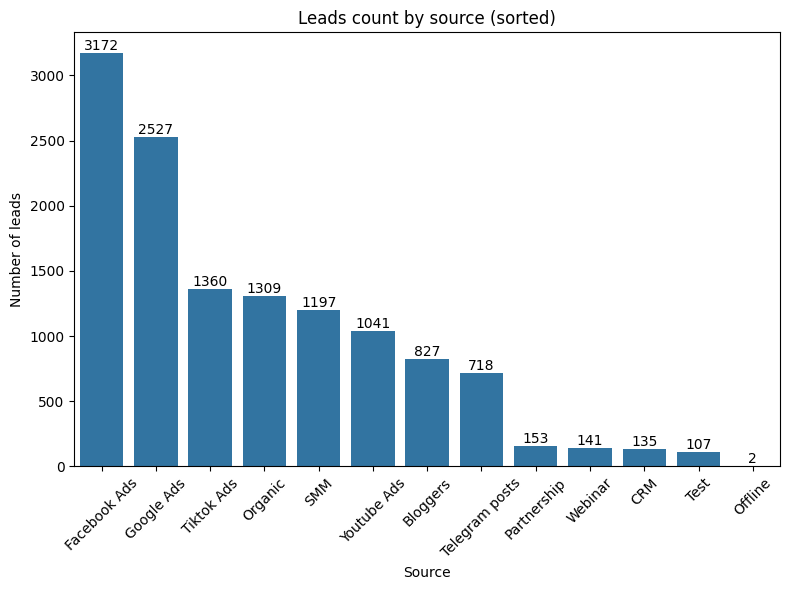

In [22]:
df_source_counts_sorted = df_source_counts.sort_values("leads_count", ascending=False)
plt.figure(figsize=(8, 6))

ax = sns.barplot(data=df_source_counts_sorted, x="Source", y="leads_count")
plt.xticks(rotation=45)
plt.xlabel("Source")
plt.ylabel("Number of leads")
plt.title("Leads count by source (sorted)")

for i, row in df_source_counts_sorted.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["leads_count"],
        int(row["leads_count"]),
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.tight_layout()
plt.show()

Step  4. Filter Quality Leads.

In [23]:
df_quality_leads = df_deals[
    (df_deals["Stage"] == "Payment Done") &
    (df_deals["Initial Amount Paid"] > 10)]
df_quality_leads.head(3)

,Id,Deal Owner Name,Closing Date,Quality,Stage,Lost Reason,Campaign,SLA,Content,Term,...,Created Time,Course duration,Months of study,Initial Amount Paid,Offer Total Amount,Contact Name,City,Level of Deutsch,SLA_status,level_norm
468,5805028000055502703,Eva Kent,2024-06-18,B - Medium,Payment Done,NaN,performancemax_wide_AT,0 days 14:35:20,_{region_name}_,NaN,...,2024-06-15 20:01:00,11.0,1.0,500.0,4500.0,5805028000055471387,Podskalie,<NA>,12 - 24h,<NA>
478,5805028000055524315,Ben Hall,2024-06-19,A - High,Payment Done,NaN,12.07.2023wide_DE,0 days 00:17:25,bloggersvideo11,wide,...,2024-06-15 17:02:00,11.0,1.0,500.0,4500.0,5805028000055503302,Zinnowitz,<NA>,10-30 min,<NA>
497,5805028000055524040,Ben Hall,2024-06-30,B - Medium,Payment Done,NaN,Live_DE,0 days 00:23:42,b0,03_06_2024,...,2024-06-15 12:20:00,6.0,1.0,1000.0,9000.0,5805028000055464156,Wolfsburg,B1,10-30 min,B1


Step  5. Quality Leads Grouped by Source.

In [24]:
df_quality_by_source = (
    df_quality_leads
    .groupby("Source", dropna=False)["Id"]
    .nunique()
    .reset_index(name="quality_leads")
    .sort_values("quality_leads", ascending=False)
)
df_quality_by_source.head(10)

,Source,quality_leads
2,Facebook Ads,196
3,Google Ads,169
4,Organic,143
6,SMM,88
9,Tiktok Ads,56
11,Youtube Ads,53
7,Telegram posts,39
0,Bloggers,39
10,Webinar,26
1,CRM,23


Step  6. Number of Quality Leads by Source.

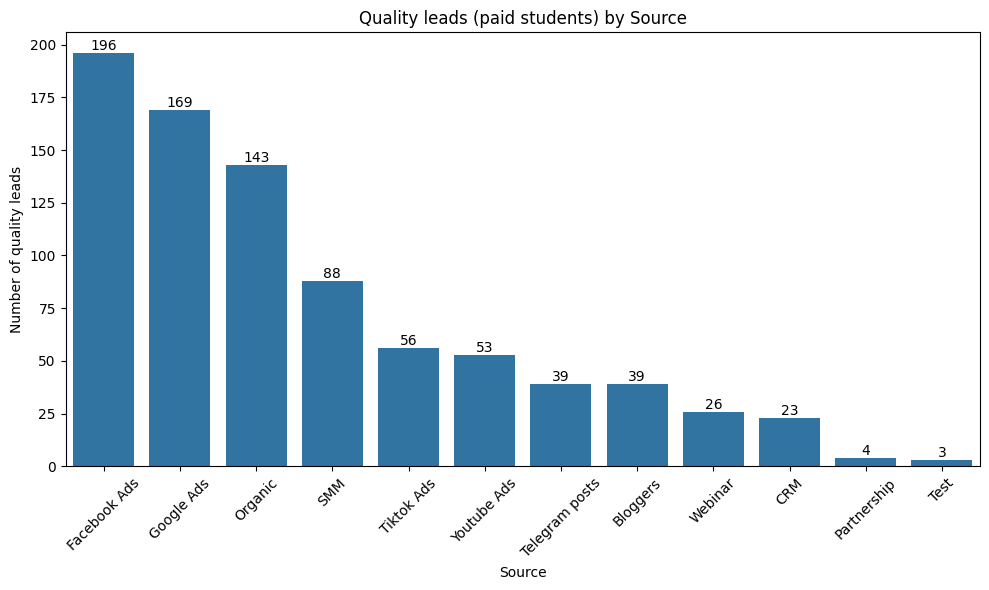

In [25]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_quality_by_source,
    x="Source",
    y="quality_leads"
)
plt.xticks(rotation=45)

plt.xlabel("Source")
plt.ylabel("Number of quality leads")
plt.title("Quality leads (paid students) by Source")

for i, row in df_quality_by_source.reset_index(drop=True).iterrows():
    ax.text(
        i, 
        row["quality_leads"],  
        int(row["quality_leads"]),  
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.tight_layout()
plt.show()

Step  7. Intermediate visualization for comparative analysis.

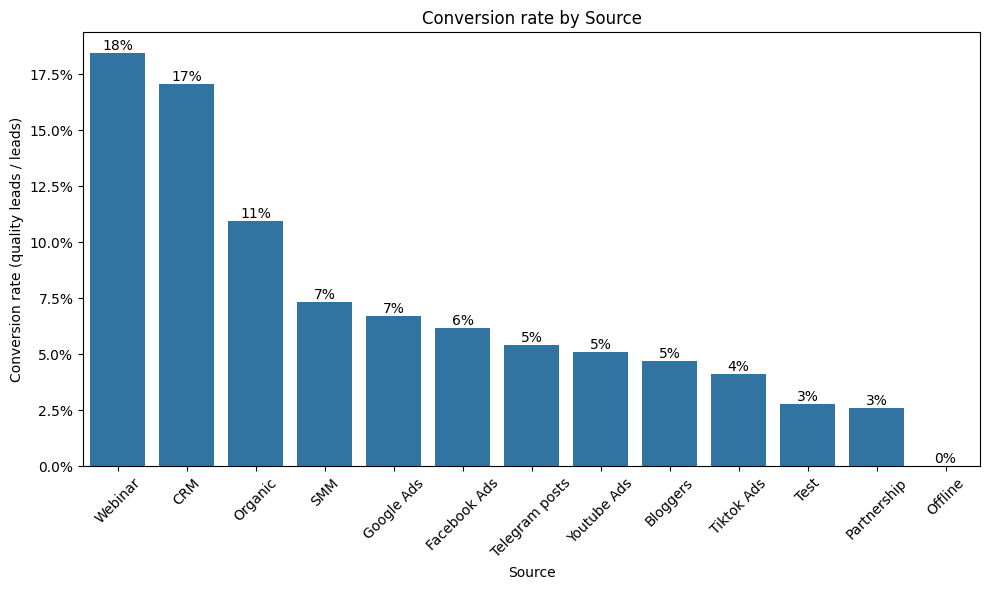

In [26]:
df_conversion = df_source_counts.merge(
    df_quality_by_source[["Source", "quality_leads"]],
    on="Source",
    how="left"
)
df_conversion["quality_leads"] = df_conversion["quality_leads"].fillna(0)

df_conversion["conversion_rate"] = (
    df_conversion["quality_leads"] / df_conversion["leads_count"]
)

df_conversion_sorted = df_conversion.sort_values(
    "conversion_rate",
    ascending=False
)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_conversion_sorted,
    x="Source",
    y="conversion_rate"
)
plt.xticks(rotation=45)
plt.xlabel("Source")
plt.ylabel("Conversion rate (quality leads / leads)")
plt.title("Conversion rate by Source")

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

for i, row in df_conversion_sorted.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["conversion_rate"],
        f"{row['conversion_rate']:.0%}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()


Step  8. Lead Volume vs. Conversion Rate by Source

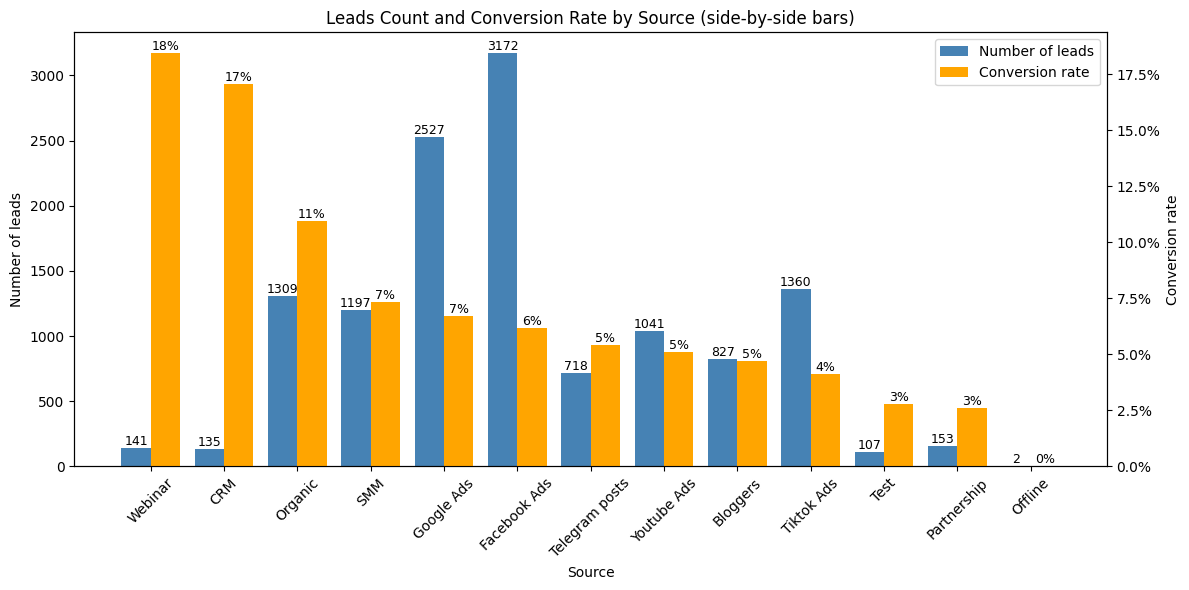

In [27]:
df_plot = df_conversion_sorted.copy()

fig, ax1 = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_plot["Source"])) 
width = 0.4  # Bar width

bar1 = ax1.bar(
    x - width/2,
    df_plot["leads_count"],
    width,
    label="Number of leads",
    color="steelblue"
)
ax1.set_xlabel("Source")
ax1.set_ylabel("Number of leads")
ax1.set_xticks(x)
ax1.set_xticklabels(df_plot["Source"], rotation=45)

ax2 = ax1.twinx()
bar2 = ax2.bar(
    x + width/2,
    df_plot["conversion_rate"],
    width,
    label="Conversion rate",
    color="orange"
)
ax2.set_ylabel("Conversion rate")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for i, val in enumerate(df_plot["leads_count"]):
    ax1.text(
        x[i] - width/2,
        val,
        str(int(val)),
        ha="center",
        va="bottom",
        fontsize=9 )

for i, val in enumerate(df_plot["conversion_rate"]):
    ax2.text(
        x[i] + width/2,
        val,
        f"{val:.0%}",
        ha="center",
        va="bottom",
        fontsize=9)

lines, labels = [], []
for axes in [ax1, ax2]:
    line, label = axes.get_legend_handles_labels()
    lines.extend(line)
    labels.extend(label)
plt.legend(lines, labels, loc="upper right")

plt.title("Leads Count and Conversion Rate by Source (side-by-side bars)")
plt.tight_layout()
plt.show()

Conclusion

The analysis revealed significant differences between traffic sources: some channels generate a high volume of leads but show low conversion rates, while others deliver fewer leads but with significantly higher quality and payment rates.
Comparing two key metrics — lead volume and conversion rate — enables precise identification of high-performing sources and highlights channels that require optimization or should be paused due to low effectiveness.